In [1]:
import sys
import os
sys.path.insert(0, '..')

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

import statsmodels.api as sm
from statsmodels.stats.diagnostic import het_breuschpagan
from statsmodels.stats.outliers_influence import variance_inflation_factor

from scripts.database import engine

sns.set_theme(style="whitegrid", palette="muted")
plt.rcParams.update({'figure.dpi': 120, 'font.size': 11})

print("✅ Librerías importadas correctamente")
print(f"   pandas      {pd.__version__}")
print(f"   numpy       {np.__version__}")
print(f"   seaborn     {sns.__version__}")
print(f"   statsmodels {sm.__version__}")

2026-04-16 04:19:18.932 
  command:

    streamlit run /usr/local/lib/python3.11/site-packages/ipykernel_launcher.py [ARGUMENTS]


✅ Librerías importadas correctamente
   pandas      2.2.3
   numpy       1.26.4
   seaborn     0.13.2
   statsmodels 0.14.0


In [2]:
QUERY = """
SELECT
    title,
    score,
    popularity,
    favorites,
    episodes,
    rank,
    type,
    year
FROM anime
WHERE score      IS NOT NULL
  AND popularity IS NOT NULL
  AND favorites  IS NOT NULL
  AND episodes   IS NOT NULL
ORDER BY rank
"""

df = pd.read_sql(QUERY, engine)

print(f"✅ Datos cargados exitosamente desde Supabase")
print(f"   Filas    : {df.shape[0]:,}")
print(f"   Columnas : {df.shape[1]}")
print(f"\n📋 Primeras filas:")
df.head()

✅ Datos cargados exitosamente desde Supabase
   Filas    : 492
   Columnas : 8

📋 Primeras filas:


,title,score,popularity,favorites,episodes,rank,type,year
0,Sousou no Frieren,9.28,108,85781,28,1.0,TV,2023.0
1,Sousou no Frieren 2nd Season,9.16,650,5418,10,2.0,TV,2026.0
2,Fullmetal Alchemist: Brotherhood,9.11,3,240854,64,3.0,TV,2009.0
3,Chainsaw Man Movie: Reze-hen,9.09,647,12022,1,4.0,Movie,NaN
4,Steins;Gate,9.07,14,201123,24,5.0,TV,2011.0


In [3]:
print("=" * 50)
print("  INFORMACIÓN GENERAL DEL DATASET")
print("=" * 50)
print(df.info())
print("\n📊 Valores nulos por columna:")
print(df.isnull().sum())
print(f"\n🎬 Tipos de anime en el dataset:")
print(df['type'].value_counts())

  INFORMACIÓN GENERAL DEL DATASET
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 492 entries, 0 to 491
Data columns (total 8 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   title       492 non-null    object 
 1   score       492 non-null    float64
 2   popularity  492 non-null    int64  
 3   favorites   492 non-null    int64  
 4   episodes    492 non-null    int64  
 5   rank        485 non-null    float64
 6   type        492 non-null    object 
 7   year        294 non-null    float64
dtypes: float64(3), int64(3), object(2)
memory usage: 30.9+ KB
None

📊 Valores nulos por columna:
title           0
score           0
popularity      0
favorites       0
episodes        0
rank            7
type            0
year          198
dtype: int64

🎬 Tipos de anime en el dataset:
type
TV            294
Movie         114
ONA            40
OVA            17
TV Special     11
Special         9
Music           6
PV              1
Name: count, dt

In [4]:
vars_num = ['score', 'popularity', 'favorites', 'episodes']

desc = df[vars_num].describe().round(2)
print("📊 ESTADÍSTICAS DESCRIPTIVAS")
print(desc)

📊 ESTADÍSTICAS DESCRIPTIVAS
        score  popularity  favorites  episodes
count  492.00      492.00     492.00    492.00
mean     8.43     1502.32   13491.87     18.36
std      0.22     1845.98   27723.09     35.42
min      8.16        1.00      24.00      1.00
25%      8.25      290.25     884.75      1.00
50%      8.37      825.00    3555.50     12.00
75%      8.57     2034.75   13552.75     24.00
max      9.28    12271.00  240854.00    500.00


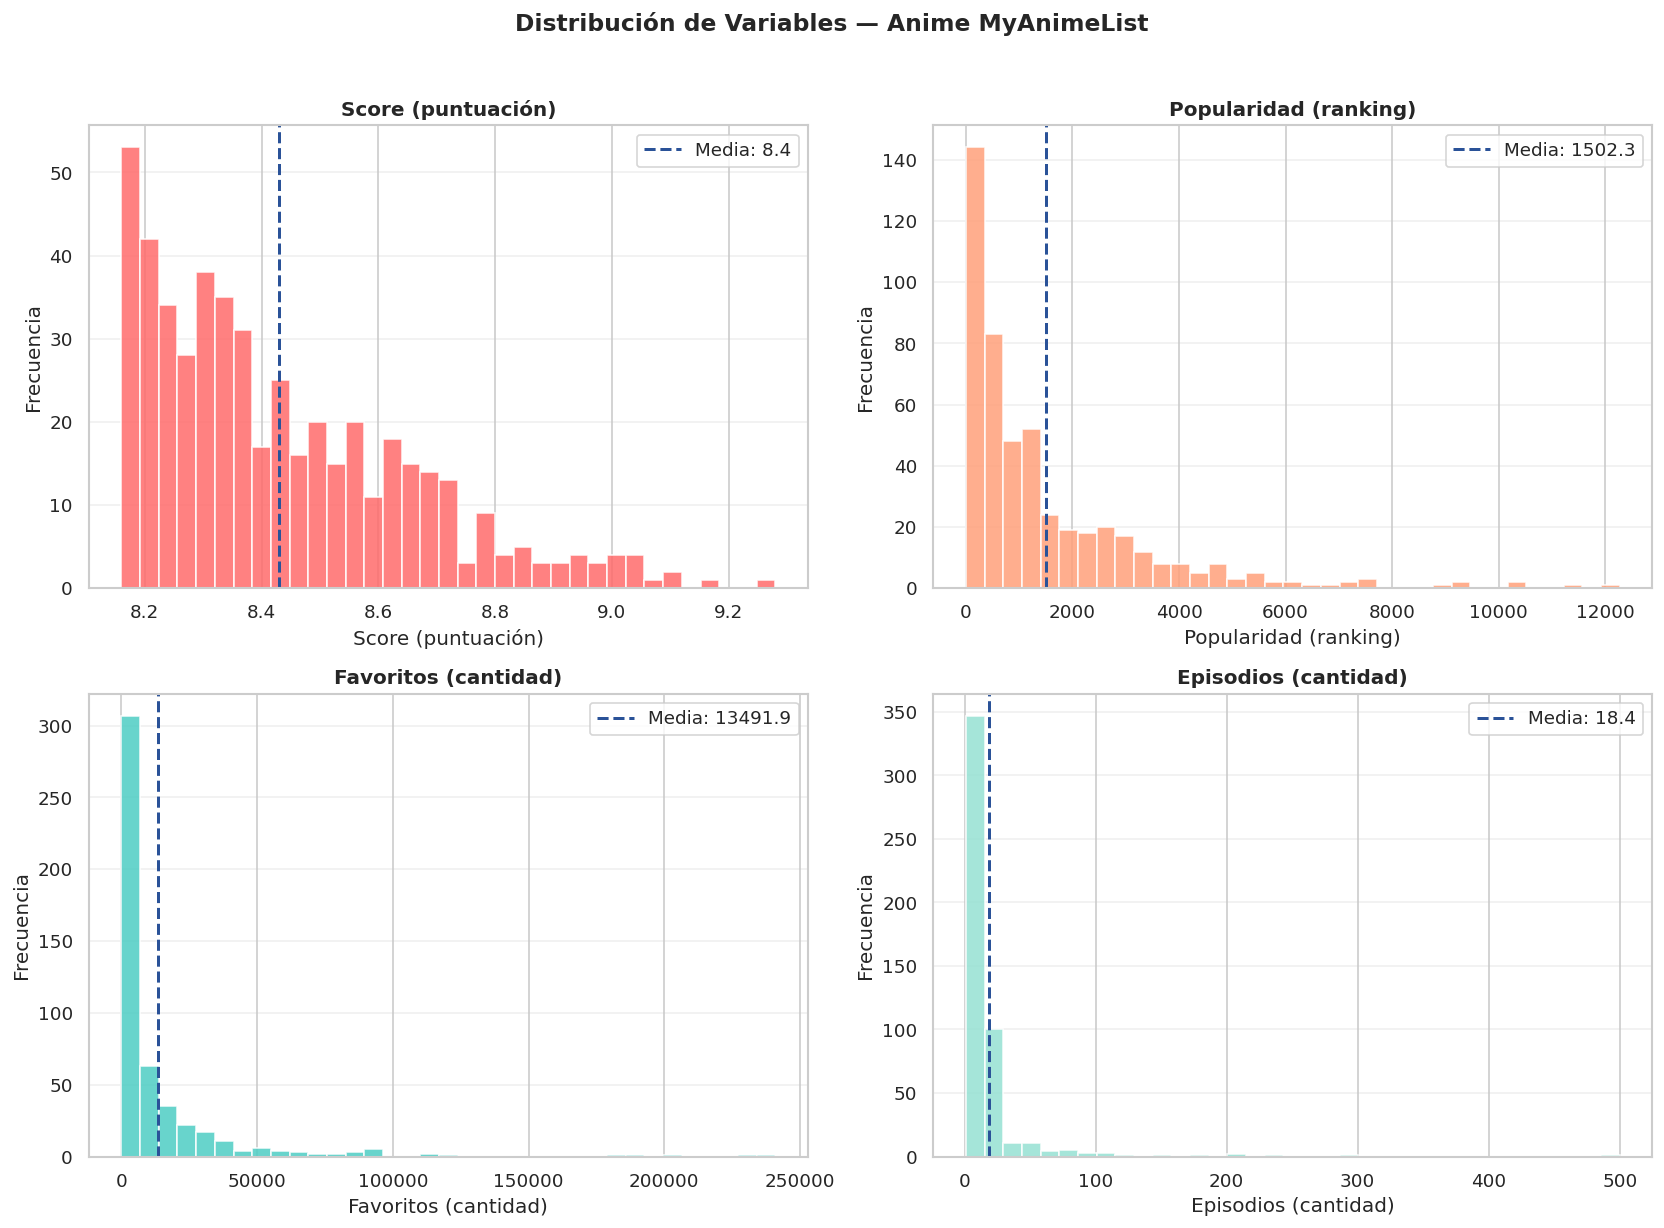

In [5]:
os.makedirs('../data/graficas', exist_ok=True)

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle('Distribución de Variables — Anime MyAnimeList',
             fontsize=14, fontweight='bold', y=1.02)

datos = {
    'score'      : ('Score (puntuación)',        '#ff6b6b'),
    'popularity' : ('Popularidad (ranking)',      '#ffa07a'),
    'favorites'  : ('Favoritos (cantidad)',       '#4ecdc4'),
    'episodes'   : ('Episodios (cantidad)',       '#95e1d3'),
}

for ax, (col, (label, color)) in zip(axes.flat, datos.items()):
    ax.hist(df[col], bins=35, color=color, edgecolor='white', alpha=0.85)
    media = df[col].mean()
    ax.axvline(media, color='#2a5298', linestyle='--', linewidth=1.8,
               label=f'Media: {media:.1f}')
    ax.set_title(label, fontweight='bold')
    ax.set_xlabel(label)
    ax.set_ylabel('Frecuencia')
    ax.legend()
    ax.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.savefig('../data/graficas/eda_distribuciones.png', dpi=300, bbox_inches='tight')
plt.show()

/tmp/ipykernel_589/2392673518.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='type', y='score', order=orden,
/tmp/ipykernel_589/2392673518.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='type', y='favorites', order=orden,


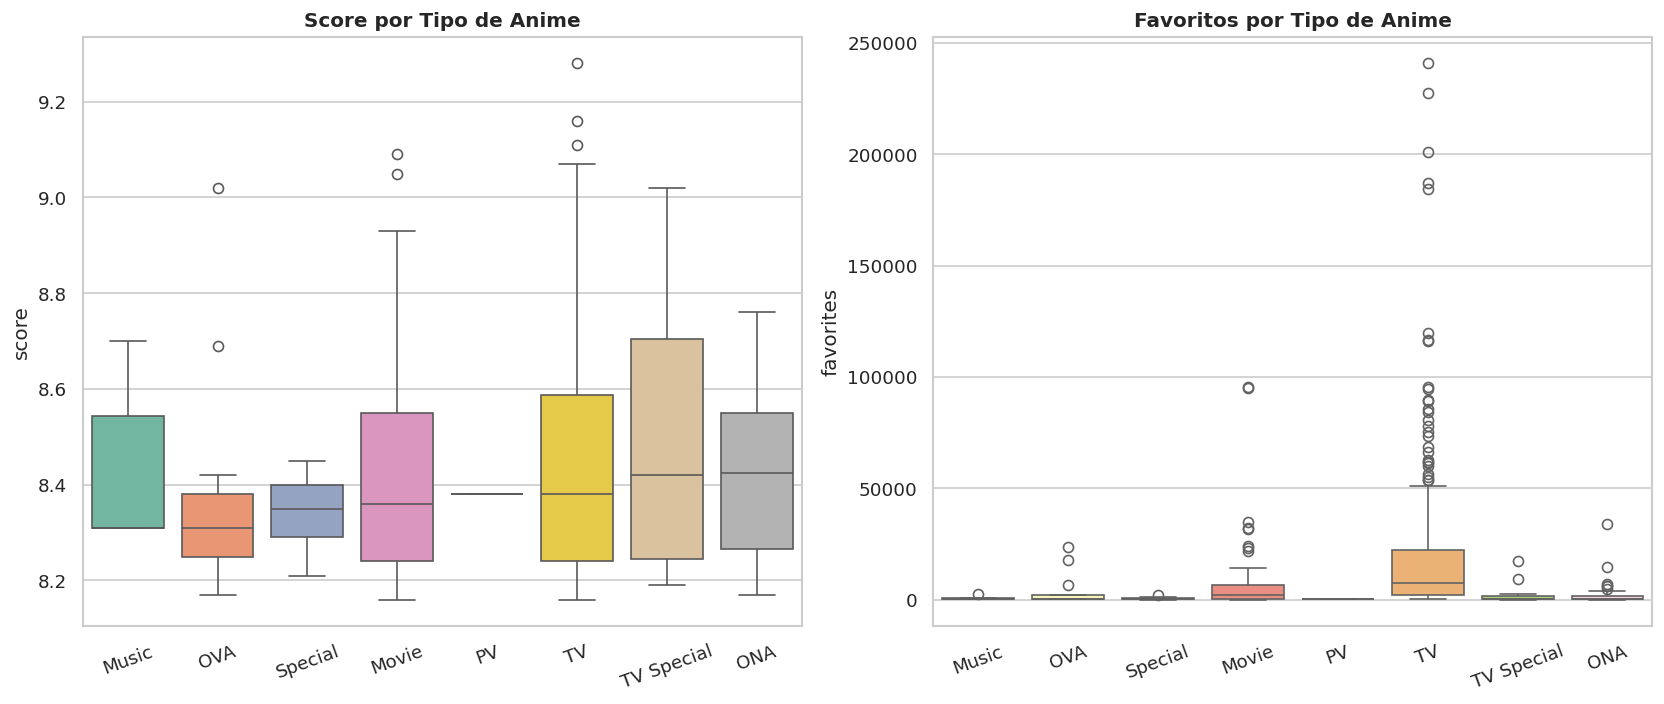

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

orden = df.groupby('type')['score'].median().sort_values().index

sns.boxplot(data=df, x='type', y='score', order=orden,
            palette='Set2', ax=axes[0])
axes[0].set_title('Score por Tipo de Anime', fontweight='bold')
axes[0].set_xlabel('')
axes[0].tick_params(axis='x', rotation=20)

sns.boxplot(data=df, x='type', y='favorites', order=orden,
            palette='Set3', ax=axes[1])
axes[1].set_title('Favoritos por Tipo de Anime', fontweight='bold')
axes[1].set_xlabel('')
axes[1].tick_params(axis='x', rotation=20)

plt.tight_layout()
plt.savefig('../data/graficas/eda_boxplots_tipo.png', dpi=150, bbox_inches='tight')
plt.show()

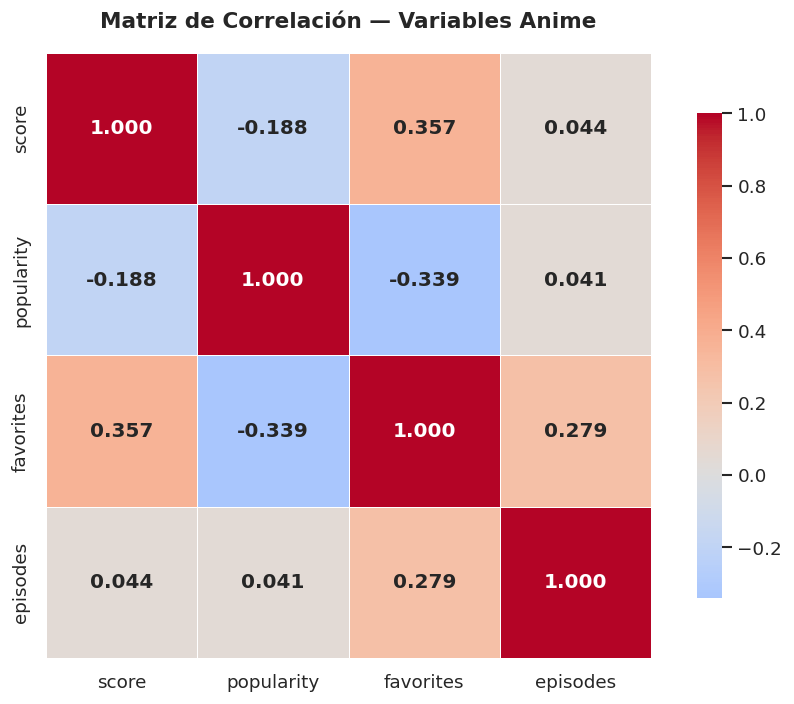


📊 Correlación con score (ordenada):
favorites     0.3575
episodes      0.0438
popularity   -0.1875
Name: score, dtype: float64


In [7]:
corr = df[vars_num].corr()

plt.figure(figsize=(8, 6))
sns.heatmap(corr, annot=True, fmt='.3f', cmap='coolwarm', center=0,
            linewidths=0.6, square=True, cbar_kws={'shrink': 0.8},
            annot_kws={'size': 12, 'weight': 'bold'})
plt.title('Matriz de Correlación — Variables Anime',
          fontsize=13, fontweight='bold', pad=15)
plt.tight_layout()
plt.savefig('../data/graficas/eda_correlacion.png', dpi=300, bbox_inches='tight')
plt.show()

print("\n📊 Correlación con score (ordenada):")
print(corr['score'].drop('score').sort_values(ascending=False).round(4))

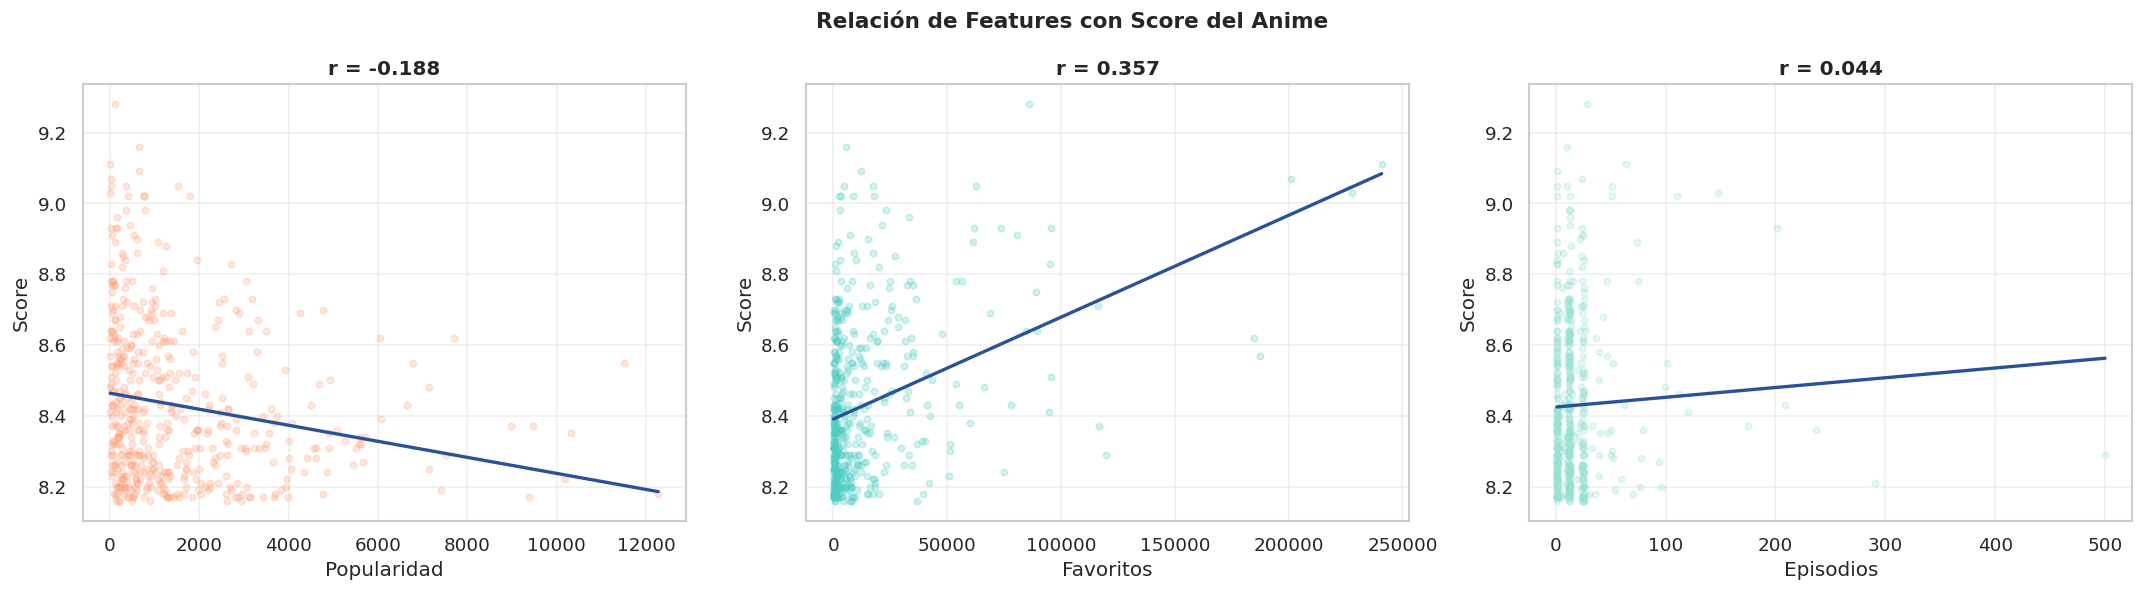

In [8]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle('Relación de Features con Score del Anime',
             fontsize=13, fontweight='bold')

pares = [
    ('popularity', 'Popularidad',       '#ffa07a'),
    ('favorites',  'Favoritos',         '#4ecdc4'),
    ('episodes',   'Episodios',         '#95e1d3'),
]

for ax, (feature, xlabel, color) in zip(axes, pares):
    ax.scatter(df[feature], df['score'], alpha=0.25, s=15, color=color)
    z = np.polyfit(df[feature], df['score'], 1)
    p = np.poly1d(z)
    xp = np.linspace(df[feature].min(), df[feature].max(), 200)
    ax.plot(xp, p(xp), color='#2a5298', linewidth=2)
    r = df[[feature, 'score']].corr().iloc[0, 1]
    ax.set_title(f'r = {r:.3f}', fontweight='bold')
    ax.set_xlabel(xlabel)
    ax.set_ylabel('Score')
    ax.grid(alpha=0.3)

plt.tight_layout()
plt.savefig('../data/graficas/eda_scatter.png', dpi=300, bbox_inches='tight')
plt.show()

In [9]:
# Variable independiente: favorites (mayor correlación con score)
X_simple = df[['favorites']].values
y        = df['score'].values

X_train, X_test, y_train, y_test = train_test_split(
    X_simple, y, test_size=0.20, random_state=42
)

print(f"Train: {X_train.shape[0]:,} muestras ({X_train.shape[0]/len(y)*100:.0f}%)")
print(f"Test : {X_test.shape[0]:,} muestras  ({X_test.shape[0]/len(y)*100:.0f}%)")

Train: 393 muestras (80%)
Test : 99 muestras  (20%)


In [10]:
modelo_simple = LinearRegression()
modelo_simple.fit(X_train, y_train)

y_pred_simple = modelo_simple.predict(X_test)

print(f"Intercepto  β₀ : {modelo_simple.intercept_:.4f}")
print(f"Coeficiente β₁ : {modelo_simple.coef_[0]:.6f}")
print(f"\nEcuación : score = {modelo_simple.intercept_:.3f}"
      f" + {modelo_simple.coef_[0]:.6f} × favorites")

Intercepto  β₀ : 8.3937
Coeficiente β₁ : 0.000003

Ecuación : score = 8.394 + 0.000003 × favorites


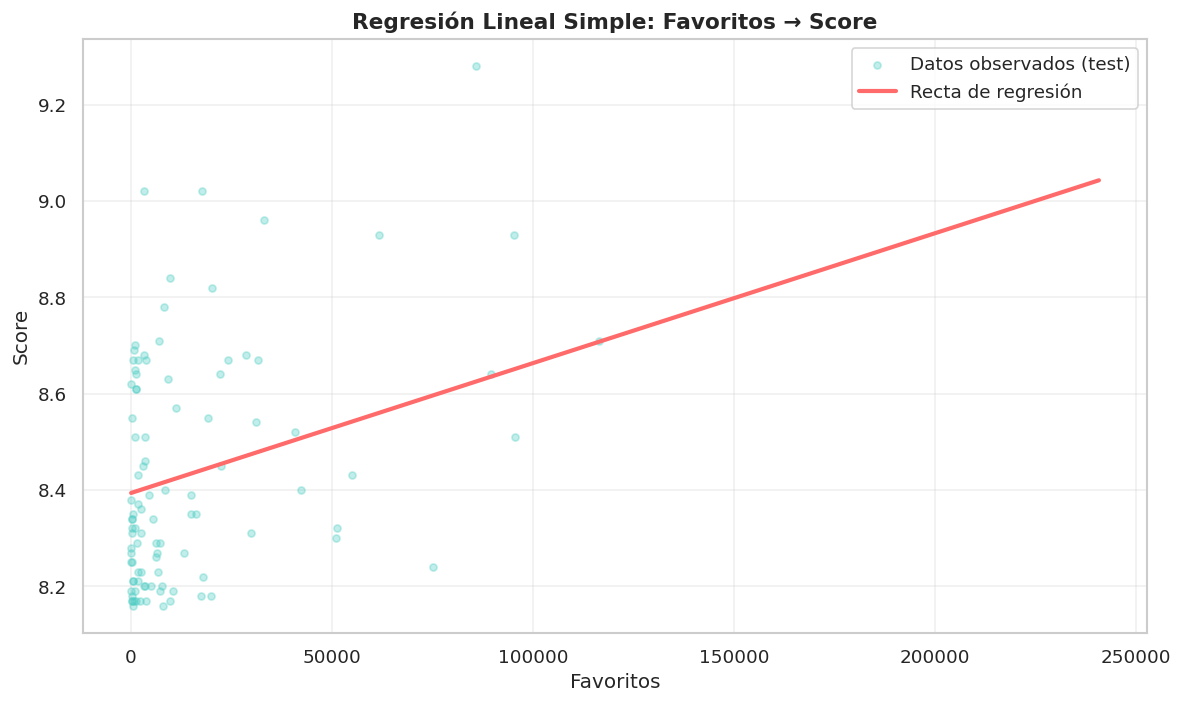

In [11]:
fig, ax = plt.subplots(figsize=(10, 6))

ax.scatter(X_test, y_test, alpha=0.35, s=18,
           color='#4ecdc4', label='Datos observados (test)')
x_line = np.linspace(X_simple.min(), X_simple.max(), 300).reshape(-1, 1)
ax.plot(x_line, modelo_simple.predict(x_line),
        color='#ff6b6b', linewidth=2.5, label='Recta de regresión')

ax.set_xlabel('Favoritos', fontsize=12)
ax.set_ylabel('Score', fontsize=12)
ax.set_title('Regresión Lineal Simple: Favoritos → Score',
             fontsize=13, fontweight='bold')
ax.legend()
ax.grid(alpha=0.3)

plt.tight_layout()
plt.savefig('../data/graficas/regresion_simple.png', dpi=300, bbox_inches='tight')
plt.show()

In [12]:
r2   = r2_score(y_test, y_pred_simple)
mse  = mean_squared_error(y_test, y_pred_simple)
rmse = np.sqrt(mse)
mae  = mean_absolute_error(y_test, y_pred_simple)

print("=" * 48)
print("    MÉTRICAS — REGRESIÓN LINEAL SIMPLE")
print("=" * 48)
print(f"  R²   (coef. determinación)  : {r2:.4f}  ({r2*100:.2f}%)")
print(f"  MSE  (error cuadrático med)  : {mse:.4f}")
print(f"  RMSE (raíz del MSE)          : {rmse:.4f}")
print(f"  MAE  (error absoluto medio)  : {mae:.4f}")
print("=" * 48)

    MÉTRICAS — REGRESIÓN LINEAL SIMPLE
  R²   (coef. determinación)  : 0.1365  (13.65%)
  MSE  (error cuadrático med)  : 0.0503
  RMSE (raíz del MSE)          : 0.2242
  MAE  (error absoluto medio)  : 0.1869


In [13]:
X_ols = sm.add_constant(df['favorites'])
modelo_ols_simple = sm.OLS(df['score'], X_ols).fit()
print(modelo_ols_simple.summary())

                            OLS Regression Results                            
Dep. Variable:                  score   R-squared:                       0.128
Model:                            OLS   Adj. R-squared:                  0.126
Method:                 Least Squares   F-statistic:                     71.79
Date:                Thu, 16 Apr 2026   Prob (F-statistic):           2.82e-16
Time:                        04:19:27   Log-Likelihood:                 73.981
No. Observations:                 492   AIC:                            -144.0
Df Residuals:                     490   BIC:                            -135.6
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const          8.3907      0.010    802.043      0.0

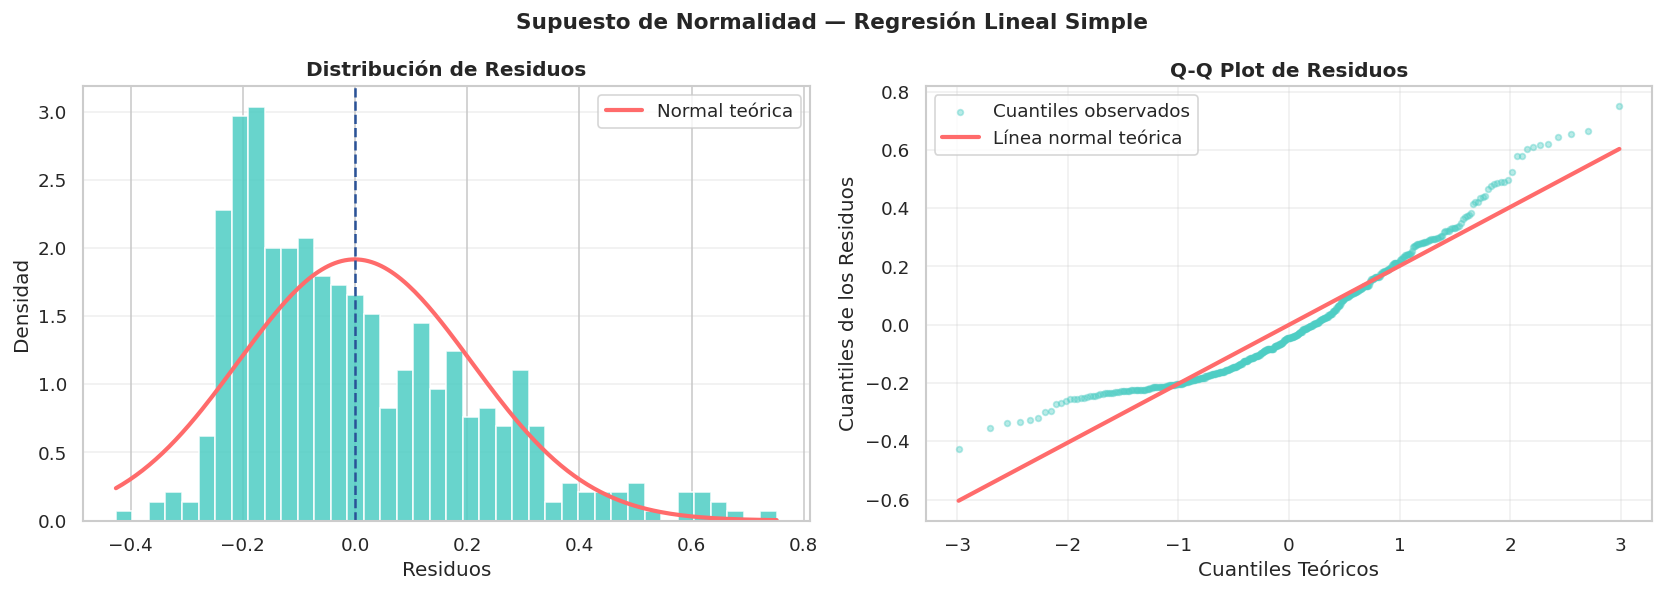


🔬 Test de Shapiro-Wilk:
   Estadístico W : 0.9316
   p-value       : 0.000000
   Conclusión    : ⚠️  Se rechaza normalidad (p ≤ 0.05)
   Nota: Con n grande el test es muy sensible — revisar Q-Q plot


In [14]:
y_pred_all = modelo_simple.predict(df[['favorites']].values)
residuos   = df['score'].values - y_pred_all

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Supuesto de Normalidad — Regresión Lineal Simple',
             fontsize=13, fontweight='bold')

axes[0].hist(residuos, bins=40, color='#4ecdc4', edgecolor='white',
             density=True, alpha=0.85)
xr = np.linspace(residuos.min(), residuos.max(), 200)
axes[0].plot(xr, stats.norm.pdf(xr, residuos.mean(), residuos.std()),
             color='#ff6b6b', linewidth=2.5, label='Normal teórica')
axes[0].axvline(0, color='#2a5298', linestyle='--', linewidth=1.5)
axes[0].set_title('Distribución de Residuos', fontweight='bold')
axes[0].set_xlabel('Residuos')
axes[0].set_ylabel('Densidad')
axes[0].legend()
axes[0].grid(axis='y', alpha=0.3)

(osm, osr), (slope, intercept, r) = stats.probplot(residuos, dist='norm')
axes[1].scatter(osm, osr, alpha=0.4, s=12, color='#4ecdc4',
                label='Cuantiles observados')
axes[1].plot(osm, slope * np.array(osm) + intercept,
             color='#ff6b6b', linewidth=2.5, label='Línea normal teórica')
axes[1].set_title('Q-Q Plot de Residuos', fontweight='bold')
axes[1].set_xlabel('Cuantiles Teóricos')
axes[1].set_ylabel('Cuantiles de los Residuos')
axes[1].legend()
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.savefig('../data/graficas/normalidad_simple.png', dpi=150, bbox_inches='tight')
plt.show()

muestra_sw = (residuos if len(residuos) <= 5000
              else np.random.default_rng(42).choice(residuos, 5000, replace=False))
stat_sw, p_sw = stats.shapiro(muestra_sw)

print(f"\n🔬 Test de Shapiro-Wilk:")
print(f"   Estadístico W : {stat_sw:.4f}")
print(f"   p-value       : {p_sw:.6f}")
if p_sw > 0.05:
    print("   Conclusión    : ✅ No se rechaza normalidad (p > 0.05)")
else:
    print("   Conclusión    : ⚠️  Se rechaza normalidad (p ≤ 0.05)")
    print("   Nota: Con n grande el test es muy sensible — revisar Q-Q plot")

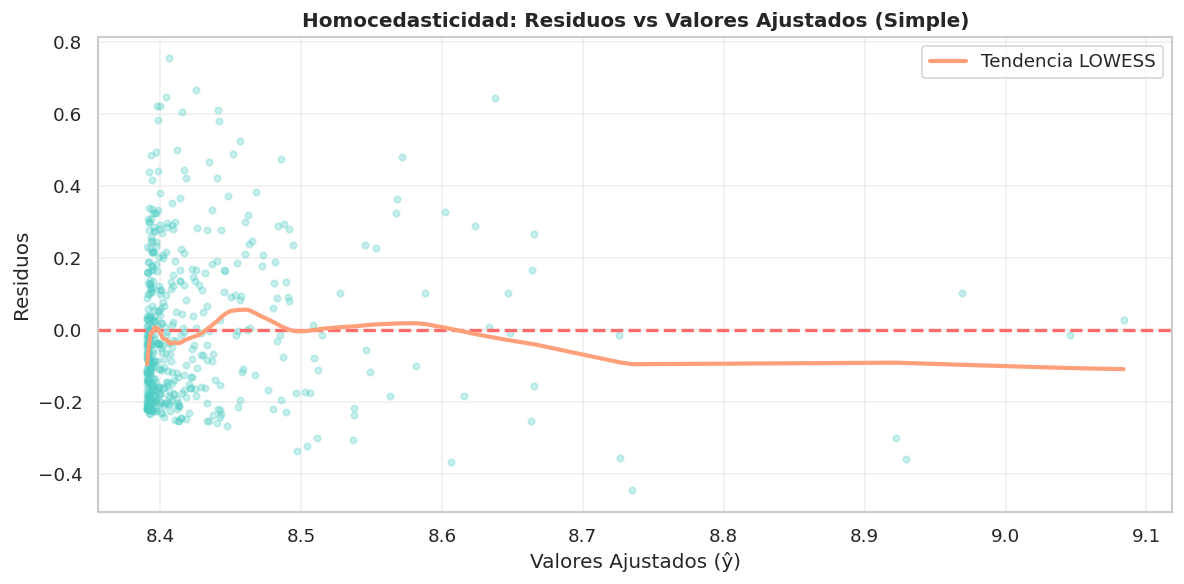


🔬 Test de Breusch-Pagan (Homocedasticidad):
   Estadístico LM : 5.0329
   p-value        : 0.024870
   Conclusión     : ⚠️  Heterocedasticidad detectada (p ≤ 0.05)


In [15]:
residuos_ols  = modelo_ols_simple.resid
ajustados_ols = modelo_ols_simple.fittedvalues

plt.figure(figsize=(10, 5))
plt.scatter(ajustados_ols, residuos_ols, alpha=0.30, s=15, color='#4ecdc4')
plt.axhline(0, color='#ff6b6b', linestyle='--', linewidth=2)
lowess = sm.nonparametric.lowess(residuos_ols, ajustados_ols, frac=0.3)
plt.plot(lowess[:, 0], lowess[:, 1], color='#ffa07a', linewidth=2.5,
         label='Tendencia LOWESS')
plt.xlabel('Valores Ajustados (ŷ)', fontsize=12)
plt.ylabel('Residuos', fontsize=12)
plt.title('Homocedasticidad: Residuos vs Valores Ajustados (Simple)',
          fontsize=12, fontweight='bold')
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.savefig('../data/graficas/homoc_simple.png', dpi=150, bbox_inches='tight')
plt.show()

lm, lm_p, fval, fp = het_breuschpagan(residuos_ols, modelo_ols_simple.model.exog)

print(f"\n🔬 Test de Breusch-Pagan (Homocedasticidad):")
print(f"   Estadístico LM : {lm:.4f}")
print(f"   p-value        : {lm_p:.6f}")
if lm_p > 0.05:
    print("   Conclusión     : ✅ Homocedasticidad (p > 0.05)")
else:
    print("   Conclusión     : ⚠️  Heterocedasticidad detectada (p ≤ 0.05)")

In [16]:
FEATURES = ['popularity', 'favorites', 'episodes']

X_multi = df[FEATURES].values
y       = df['score'].values

X_train_m, X_test_m, y_train_m, y_test_m = train_test_split(
    X_multi, y, test_size=0.20, random_state=42
)

modelo_multi = LinearRegression()
modelo_multi.fit(X_train_m, y_train_m)

y_pred_multi = modelo_multi.predict(X_test_m)

print(f"Intercepto  β₀              : {modelo_multi.intercept_:.4f}")
for feat, coef in zip(FEATURES, modelo_multi.coef_):
    print(f"Coeficiente {feat:>18} : {coef:.6f}")

Intercepto  β₀              : 8.4182
Coeficiente         popularity : -0.000009
Coeficiente          favorites : 0.000003
Coeficiente           episodes : -0.000524


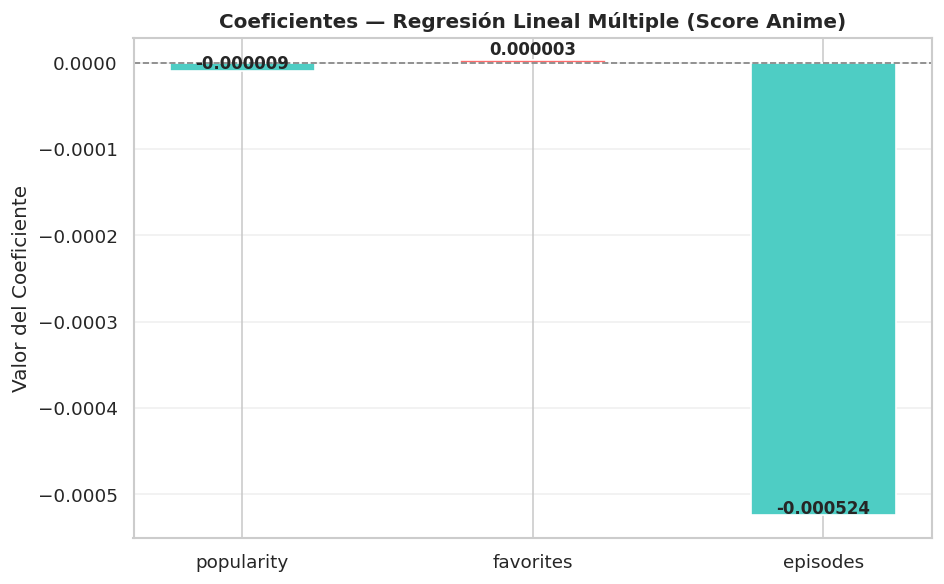

In [17]:
colores = ['#ff6b6b' if c > 0 else '#4ecdc4' for c in modelo_multi.coef_]

fig, ax = plt.subplots(figsize=(8, 5))
bars = ax.bar(FEATURES, modelo_multi.coef_,
              color=colores, edgecolor='white', width=0.5)
ax.axhline(0, color='gray', linestyle='--', linewidth=1)
ax.set_title('Coeficientes — Regresión Lineal Múltiple (Score Anime)',
             fontsize=12, fontweight='bold')
ax.set_ylabel('Valor del Coeficiente')

for bar, coef in zip(bars, modelo_multi.coef_):
    offset = 0.000002 if coef >= 0 else -0.000002
    ax.text(bar.get_x() + bar.get_width() / 2,
            bar.get_height() + offset,
            f'{coef:.6f}', ha='center', va='bottom',
            fontsize=10, fontweight='bold')

ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.savefig('../data/graficas/coeficientes_multi.png', dpi=300, bbox_inches='tight')
plt.show()

In [18]:
r2_m   = r2_score(y_test_m, y_pred_multi)
mse_m  = mean_squared_error(y_test_m, y_pred_multi)
rmse_m = np.sqrt(mse_m)
mae_m  = mean_absolute_error(y_test_m, y_pred_multi)

print("=" * 48)
print("  MÉTRICAS — REGRESIÓN LINEAL MÚLTIPLE")
print("=" * 48)
print(f"  R²   (coef. determinación)  : {r2_m:.4f}  ({r2_m*100:.2f}%)")
print(f"  MSE  (error cuadrático med)  : {mse_m:.4f}")
print(f"  RMSE (raíz del MSE)          : {rmse_m:.4f}")
print(f"  MAE  (error absoluto medio)  : {mae_m:.4f}")
print("=" * 48)

  MÉTRICAS — REGRESIÓN LINEAL MÚLTIPLE
  R²   (coef. determinación)  : 0.1121  (11.21%)
  MSE  (error cuadrático med)  : 0.0517
  RMSE (raíz del MSE)          : 0.2274
  MAE  (error absoluto medio)  : 0.1887


In [19]:
X_ols_m = sm.add_constant(df[FEATURES])
modelo_ols_multi = sm.OLS(df['score'], X_ols_m).fit()
print(modelo_ols_multi.summary())

                            OLS Regression Results                            
Dep. Variable:                  score   R-squared:                       0.135
Model:                            OLS   Adj. R-squared:                  0.130
Method:                 Least Squares   F-statistic:                     25.41
Date:                Thu, 16 Apr 2026   Prob (F-statistic):           2.75e-15
Time:                        04:19:29   Log-Likelihood:                 76.049
No. Observations:                 492   AIC:                            -144.1
Df Residuals:                     488   BIC:                            -127.3
Df Model:                           3                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const          8.4098      0.014    580.668      0.0

In [20]:
X_vif = df[FEATURES].copy()

vif_data = pd.DataFrame({
    "Variable": FEATURES,
    "VIF": [
        variance_inflation_factor(X_vif.values, i)
        for i in range(X_vif.shape[1])
    ]
})
vif_data["VIF"] = vif_data["VIF"].round(3)
vif_data["Criterio"] = vif_data["VIF"].apply(
    lambda v: "✅ Sin multicolinealidad (VIF < 5)"
              if v < 5
              else ("⚠️  Moderada (5 ≤ VIF < 10)"
                    if v < 10
                    else "❌ Severa (VIF ≥ 10)")
)

print("\n📊 FACTOR DE INFLACIÓN DE LA VARIANZA (VIF)")
print("=" * 60)
print(vif_data.to_string(index=False))
print("=" * 60)


📊 FACTOR DE INFLACIÓN DE LA VARIANZA (VIF)
  Variable   VIF                          Criterio
popularity 1.127 ✅ Sin multicolinealidad (VIF < 5)
 favorites 1.234 ✅ Sin multicolinealidad (VIF < 5)
  episodes 1.372 ✅ Sin multicolinealidad (VIF < 5)


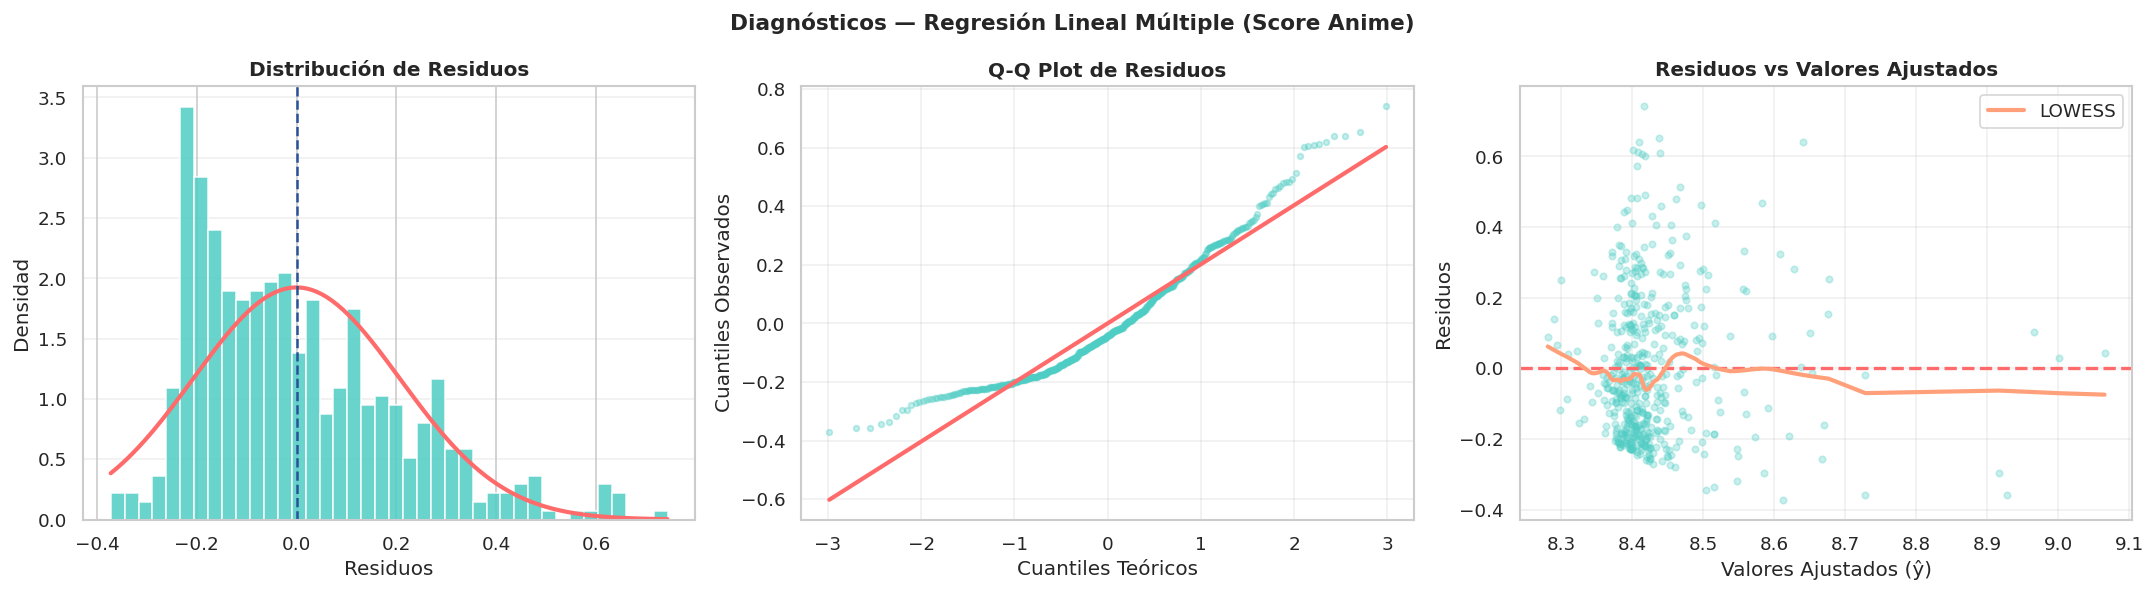


🔬 Test Shapiro-Wilk (Normalidad):
   p-value: 0.000000 → ⚠️  Se rechaza normalidad

🔬 Test Breusch-Pagan (Homocedasticidad):
   p-value: 0.009520 → ⚠️  Heterocedasticidad detectada


In [21]:
residuos_m  = modelo_ols_multi.resid.values
ajustados_m = modelo_ols_multi.fittedvalues.values

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle('Diagnósticos — Regresión Lineal Múltiple (Score Anime)',
             fontsize=13, fontweight='bold')

axes[0].hist(residuos_m, bins=40, color='#4ecdc4', edgecolor='white',
             density=True, alpha=0.85)
xr = np.linspace(residuos_m.min(), residuos_m.max(), 200)
axes[0].plot(xr, stats.norm.pdf(xr, residuos_m.mean(), residuos_m.std()),
             color='#ff6b6b', linewidth=2.5)
axes[0].axvline(0, color='#2a5298', linestyle='--')
axes[0].set_title('Distribución de Residuos', fontweight='bold')
axes[0].set_xlabel('Residuos')
axes[0].set_ylabel('Densidad')
axes[0].grid(axis='y', alpha=0.3)

(osm, osr), (s, i, _) = stats.probplot(residuos_m, dist='norm')
axes[1].scatter(osm, osr, alpha=0.35, s=12, color='#4ecdc4')
axes[1].plot(osm, s * np.array(osm) + i, color='#ff6b6b', linewidth=2.5)
axes[1].set_title('Q-Q Plot de Residuos', fontweight='bold')
axes[1].set_xlabel('Cuantiles Teóricos')
axes[1].set_ylabel('Cuantiles Observados')
axes[1].grid(alpha=0.3)

axes[2].scatter(ajustados_m, residuos_m, alpha=0.30, s=15, color='#4ecdc4')
axes[2].axhline(0, color='#ff6b6b', linestyle='--', linewidth=2)
lowess_m = sm.nonparametric.lowess(residuos_m, ajustados_m, frac=0.3)
axes[2].plot(lowess_m[:, 0], lowess_m[:, 1],
             color='#ffa07a', linewidth=2.5, label='LOWESS')
axes[2].set_title('Residuos vs Valores Ajustados', fontweight='bold')
axes[2].set_xlabel('Valores Ajustados (ŷ)')
axes[2].set_ylabel('Residuos')
axes[2].legend()
axes[2].grid(alpha=0.3)

plt.tight_layout()
plt.savefig('../data/graficas/diagnosticos_multi.png', dpi=150, bbox_inches='tight')
plt.show()

muestra_m = (residuos_m if len(residuos_m) <= 5000
             else np.random.default_rng(42).choice(residuos_m, 5000, replace=False))
stat_sw_m, p_sw_m = stats.shapiro(muestra_m)
lm_m, lm_p_m, _, _ = het_breuschpagan(modelo_ols_multi.resid,
                                       modelo_ols_multi.model.exog)

print(f"\n🔬 Test Shapiro-Wilk (Normalidad):")
print(f"   p-value: {p_sw_m:.6f} → "
      f"{'✅ No se rechaza normalidad' if p_sw_m > 0.05 else '⚠️  Se rechaza normalidad'}")

print(f"\n🔬 Test Breusch-Pagan (Homocedasticidad):")
print(f"   p-value: {lm_p_m:.6f} → "
      f"{'✅ Homocedasticidad OK' if lm_p_m > 0.05 else '⚠️  Heterocedasticidad detectada'}")

In [22]:
comparacion = pd.DataFrame({
    'Modelo'   : ['Regresión Simple', 'Regresión Múltiple'],
    'Variables': ['favorites',
                  'popularity + favorites + episodes'],
    'R²'       : [round(r2, 4),    round(r2_m, 4)],
    'R² Aj.'   : [round(modelo_ols_simple.rsquared_adj, 4),
                  round(modelo_ols_multi.rsquared_adj, 4)],
    'RMSE'     : [round(rmse, 4),  round(rmse_m, 4)],
    'MAE'      : [round(mae, 4),   round(mae_m, 4)],
    'AIC'      : [round(modelo_ols_simple.aic, 2),
                  round(modelo_ols_multi.aic, 2)],
    'BIC'      : [round(modelo_ols_simple.bic, 2),
                  round(modelo_ols_multi.bic, 2)],
})

print("=" * 80)
print("              COMPARACIÓN DE MODELOS")
print("=" * 80)
print(comparacion.to_string(index=False))
print("=" * 80)
print("\n📌 AIC/BIC más bajo → mejor equilibrio entre ajuste y parsimonia")

              COMPARACIÓN DE MODELOS
            Modelo                         Variables     R²  R² Aj.   RMSE    MAE     AIC     BIC
  Regresión Simple                         favorites 0.1365  0.1260 0.2242 0.1869 -143.96 -135.57
Regresión Múltiple popularity + favorites + episodes 0.1121  0.1298 0.2274 0.1887 -144.10 -127.30

📌 AIC/BIC más bajo → mejor equilibrio entre ajuste y parsimonia


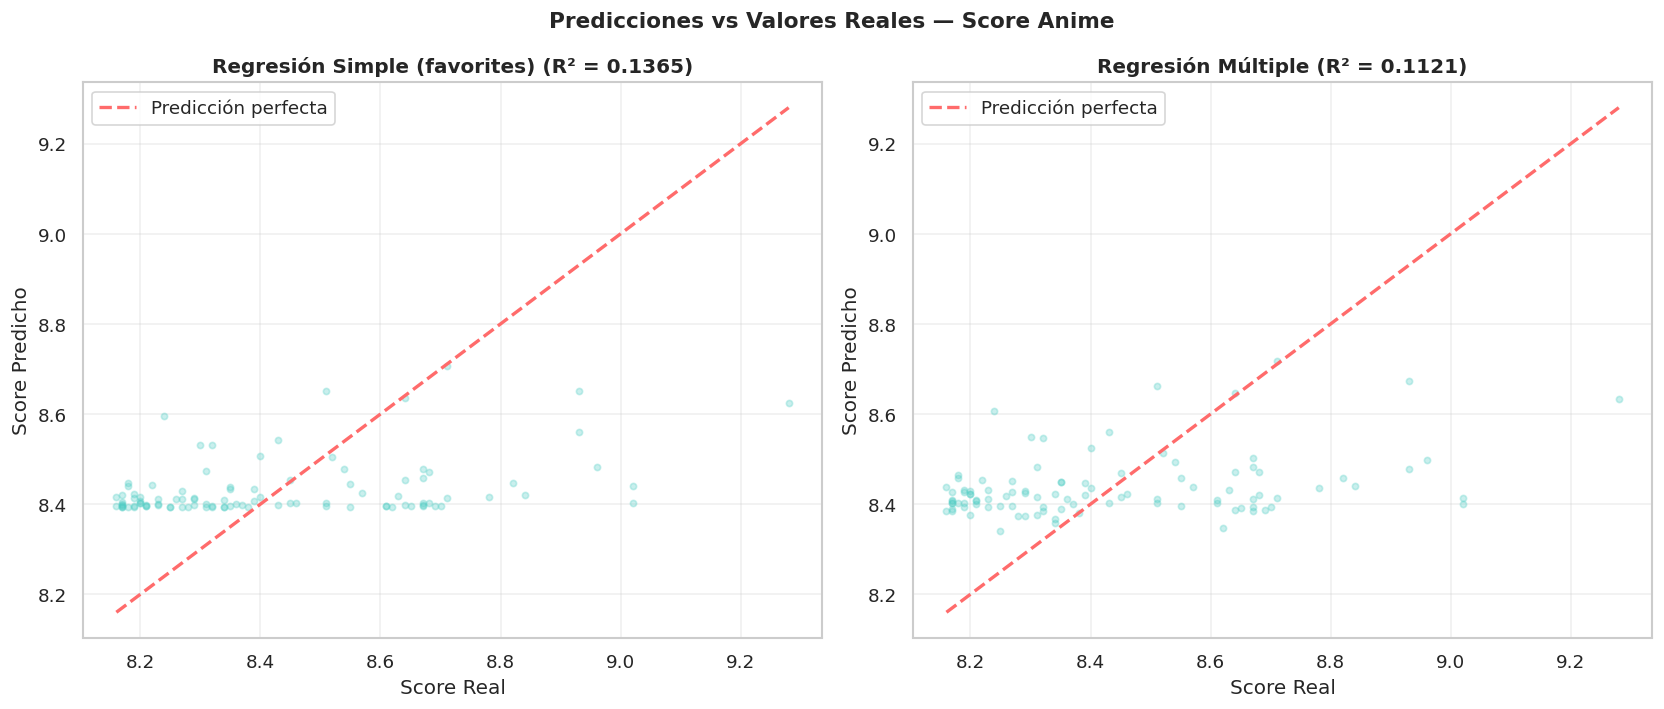

In [23]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6))
fig.suptitle('Predicciones vs Valores Reales — Score Anime',
             fontsize=13, fontweight='bold')

for ax, (y_real, y_pred, titulo) in zip(axes, [
    (y_test,   y_pred_simple, 'Regresión Simple (favorites)'),
    (y_test_m, y_pred_multi,  'Regresión Múltiple'),
]):
    minval = min(y_real.min(), y_pred.min())
    maxval = max(y_real.max(), y_pred.max())
    ax.scatter(y_real, y_pred, alpha=0.30, s=14, color='#4ecdc4')
    ax.plot([minval, maxval], [minval, maxval],
            color='#ff6b6b', linewidth=2, linestyle='--',
            label='Predicción perfecta')
    r2_val = r2_score(y_real, y_pred)
    ax.set_title(f'{titulo} (R² = {r2_val:.4f})', fontweight='bold')
    ax.set_xlabel('Score Real')
    ax.set_ylabel('Score Predicho')
    ax.legend()
    ax.grid(alpha=0.3)

plt.tight_layout()
plt.savefig('../data/graficas/predicciones_vs_reales.png', dpi=150, bbox_inches='tight')
plt.show()